# Tarea para el Hogar 05 — versión Python

Adaptación de `z494_python.ipynb` a la lógica de `z495_GustavoPasquini.ipynb`. La carga del dataset y la generación de la clase ternaria permanecen sin cambios.

# Librerías

In [1]:
import os
import cudf
import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
import optuna
from optuna.samplers import GPSampler
from optuna.trial import TrialState
from optuna.visualization import plot_param_importances, plot_contour,  plot_slice, plot_optimization_history




print('cuDF:', cudf.__version__)
print('GPU:', cp.cuda.runtime.getDeviceProperties(0)['name'].decode())



cuDF: 26.08.01
GPU: NVIDIA GeForce RTX 3090


In [2]:
import lightgbm as lgb
import yaml

In [3]:
# dispongo la carpeta con funciones e importo ternara. 
from pathlib import Path
import sys

# Obtiene la ruta del directorio actual y sube un nivel (.parent)
raiz_proyecto = Path().resolve().parent

# Agrega la ruta al sistema si no está ya incluida
if str(raiz_proyecto) not in sys.path:
  sys.path.append(str(raiz_proyecto))

# Importa tu librería o módulo
from funciones.ternaria import ternaria


# URLs

In [4]:
BASE_URL = os.path.join(
    os.path.expanduser("~"),
    "code", "DMEyF", "dmeyf2026"
)
BASE_DATA_URL = os.path.join('/mnt/', 'e')
DATA_FOLDER = os.path.join(BASE_DATA_URL, 'DATASETS', 'DMEyF')

DATA_URL = os.path.join(BASE_URL, "DATA")
DATASETS_URL = os.path.join(DATA_URL, "DATASETS")
EXP_URL = os.path.join(DATA_URL, "EXP")
dataset_url = os.path.join(DATASETS_URL, "competencia_01_crudo.csv")
DATA_TERNARIA_URL = os.path.join(DATA_FOLDER, 'competencia_01_ternaria.csv')
DATA_LAGS_URL = os.path.join(DATA_FOLDER, 'competencia_01_ternaria_lags.csv')
DATA_LAGS_FRAC_URL = os.path.join(DATA_FOLDER, 'competencia_01_ternaria_lf_k6_perdida4.csv')



experiment_name = "LAG-003"
EXPERIMENT_URL = os.path.join(EXP_URL, experiment_name)

os.makedirs(EXPERIMENT_URL, exist_ok=True)

In [5]:
os.listdir(DATA_FOLDER)

['competencia_01_crudo.csv',
 'competencia_01_ternaria.csv',
 'competencia_01_ternaria_lags.csv',
 'competencia_01_ternaria_lf_k6_perdida4.csv',
 'data_dict.csv',
 'DiccionarioDatos_2026.ods']

# Constantes

In [6]:
SEED = 230047

In [7]:
PARAM = {
    "experimento": "LAG-003",
    "semilla_primigenia": SEED,
    "training_pct": 70,
    "train": [202104],
    "train_final": [202104],
    "future": [202106],
    "cortes": list(range(9_000, 15_001, 500)),
    "trainingstrategy": {"undersampling": 0.1},
    "hyperparametertuning": {
        "iteraciones": 150,
        "n_startup_trials": 50,
        "xval_folds" : 5
    },
    "lgbm": {
        "param_fijos": {
            "boosting": "gbdt",
            "objective": "binary",
            "metric": "auc",
            "feature_pre_filter": False,
            "first_metric_only": False,
            "boost_from_average": True,
            "force_row_wise": True,
            "deterministic": True,
            "verbosity": -100,
            "seed": SEED,
            "max_depth": -1,
            "min_gain_to_split": 0.0,
            "lambda_l1": 0.0,
            "lambda_l2": 0.0,
            "max_bin": 31,
            "bagging_fraction": 1.0,
            "pos_bagging_fraction": 1.0,
            "neg_bagging_fraction": 1.0,
            "is_unbalance": False,
            "scale_pos_weight": 1.0,
            "drop_rate": 0.1,
            "max_drop": 50,
            "skip_drop": 0.5,
            "extra_trees": False,
            "early_stopping": 0,
            "min_data_in_leaf": 0,
            "feature_fraction": 0.50,
            # "learning_rate": 0.005,
  
        }
    },
    "out": {"lgbm": {}},
}


# Lectura del dataset

In [8]:
# cudf no pandas -> GPU
df = cudf.read_csv(
    DATA_LAGS_FRAC_URL,
    dtype={'numero_de_cliente': 'int32', 'foto_mes': 'int32'}
)

In [9]:
df.head()

,numero_de_cliente,foto_mes,active_quarter,cliente_vip,internet,cliente_edad,cliente_antiguedad,mrentabilidad,mrentabilidad_annual,mcomisiones,...,Visa_madelantodolares_delta_lag_pond,Visa_fultimo_cierre_delta_lag_pond,Visa_mpagado_delta_lag_pond,Visa_mpagospesos_delta_lag_pond,Visa_mpagosdolares_delta_lag_pond,Visa_fechaalta_delta_lag_pond,Visa_mconsumototal_delta_lag_pond,Visa_cconsumos_delta_lag_pond,Visa_cadelantosefectivo_delta_lag_pond,Visa_mpagominimo_delta_lag_pond
0,12159854,202103,1,0,0,56,134,688.41,26701.84,98.82,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,12159854,202104,1,0,0,56,135,1622.57,27663.64,931.59,...,0.0,1.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0
2,12159854,202105,1,0,0,56,136,1987.98,28738.37,934.07,...,0.0,3.375,0.0,1.818989404e-12,0.0,42.25,0.0,0.0,0.0,0.0
3,12159854,202106,1,0,0,56,137,2580.75,29494.76,915.19,...,0.0,-3.346938776,0.0,1.818989404e-12,0.0,50.69387755,0.0,0.0,0.0,0.0
4,12159854,202107,1,0,0,56,138,2686.85,29431.10,688.94,...,0.0,1.191176471,0.0,3.637978807e-12,0.0,58.39705882,0.0,0.0,0.0,0.0


In [10]:
cudf.crosstab(df['ternaria'].fillna('NA'), df['foto_mes'])

foto_mes,202103,202104,202105,202106,202107,202108
ternaria,,,,,,
BAJA+1,1019,964,1143,874,1103,0
BAJA+2,960,1139,870,1098,0,0
NA,0,0,0,0,163245,164647
continua,160921,161181,161755,162142,0,0


In [11]:
df_completo = df.copy()

# Optimización de hiperparámetros

Se replica el presupuesto de z495: 10 evaluaciones totales. Como `mlr3mbo` usa por defecto un diseño inicial aleatorio de tamaño `4D` y aquí `D=3`, el presupuesto se agota durante la inicialización. En Optuna se reproduce con `n_startup_trials=10`, sin LHS explícito.

## Preprocesamiento

In [12]:
dataset_train_cpu = (
    df_completo
    .loc[df_completo["foto_mes"].isin(PARAM["train"])]
    .to_pandas()
    .reset_index(drop=True)
)

# Partición estratificada 70/30, equivalente a fold 1 y fold 2 en z495.
indices_fold_1, indices_fold_2 = train_test_split(
    np.arange(len(dataset_train_cpu)),
    train_size=PARAM["training_pct"] / 100,
    stratify=dataset_train_cpu["ternaria"],
    random_state=PARAM["semilla_primigenia"],
)

dataset_train_cpu["fold"] = np.int8(2)
dataset_train_cpu.loc[indices_fold_1, "fold"] = np.int8(1)

# BAJA+1 y BAJA+2 forman la clase positiva, igual que en el R.
dataset_train_cpu["clase01"] = (
    dataset_train_cpu["ternaria"].isin(["BAJA+1", "BAJA+2"])
    .astype(np.int8)
)

rng = np.random.default_rng(PARAM["semilla_primigenia"])
dataset_train_cpu["azar"] = rng.random(len(dataset_train_cpu))
dataset_train_cpu["training"] = (
    dataset_train_cpu["fold"].eq(1)
    & (
        (dataset_train_cpu["azar"] <= PARAM["trainingstrategy"]["undersampling"])
        | dataset_train_cpu["ternaria"].isin(["BAJA+1", "BAJA+2"])
    )
).astype(np.int8)

columnas_excluidas = {
    "ternaria",
    "ternaria_lag1",
    "clase01",
    "fold",
    "azar",
    "training",
    "cprestamos_personales",
    "cprestamos_personales_lag1",
    "cprestamos_personales_delta1",
    "mprestamos_personales",
    "mprestamos_personales_lag1",
    "mprestamos_personales_delta1"
}

campos_buenos = [
    columna
    for columna in dataset_train_cpu.columns
    if columna not in columnas_excluidas
]

mask_training = dataset_train_cpu["training"].eq(1)
X_train_bo = dataset_train_cpu.loc[mask_training, campos_buenos]
y_train_bo = dataset_train_cpu.loc[mask_training, "clase01"]

# Replica literalmente z495: validation contiene todas las filas con training == 0.
mask_validation = dataset_train_cpu["training"].eq(0)
X_validate_bo = dataset_train_cpu.loc[mask_validation, campos_buenos]
y_validate_bo = dataset_train_cpu.loc[mask_validation, "clase01"]

dtrain = lgb.Dataset(
    data=X_train_bo,
    label=y_train_bo,
    feature_name=campos_buenos,
    free_raw_data=False,
)

dvalidate = lgb.Dataset(
    data=X_validate_bo,
    label=y_validate_bo,
    feature_name=campos_buenos,
    free_raw_data=False,
)

print("Filas para training:", len(X_train_bo))
print("Filas para validation:", len(X_validate_bo))
print("Columnas:", len(campos_buenos))
dataset_train_cpu.groupby(["fold", "ternaria", "training"]).size()

Filas para training: 12698
Filas para validation: 150586
Columnas: 456


fold  ternaria  training
1     BAJA+1    1              675
      BAJA+2    1              797
      continua  0           101600
                1            11226
2     BAJA+1    0              289
      BAJA+2    0              342
      continua  0            48355
dtype: int64

## Función objetivo: Average Precision sobre validation

In [13]:
def estimar_auc_lightgbm(parametros_variables):
    parametros_completos = {
        **PARAM["lgbm"]["param_fijos"],
        **parametros_variables,
    }

    # En Python conviene pasar el número de árboles por su argumento dedicado.
    num_boost_round = int(parametros_completos.pop("num_iterations"))

    resultados_cv = lgb.cv(
        params=parametros_completos,
        train_set=dtrain,
        num_boost_round=num_boost_round,
        nfold=PARAM["hyperparametertuning"]["xval_folds"],
        stratified=True,
        shuffle=True,
        seed=PARAM["semilla_primigenia"],
    )

    clave_auc = next(
        clave for clave in resultados_cv
        if clave.endswith("auc-mean")
    )

    # Sin early stopping, equivale al score al finalizar num_iterations.
    return float(resultados_cv[clave_auc][-1])

In [14]:
def estimar_ap_lightgbm(parametros_variables):
    parametros_completos = {
        **PARAM["lgbm"]["param_fijos"],
        **parametros_variables,
    }

    num_boost_round = int(parametros_completos.pop("num_iterations"))

    modelo = lgb.train(
        params=parametros_completos,
        train_set=dtrain,
        num_boost_round=num_boost_round,
        valid_sets=[dvalidate],
        valid_names=["val"],
    )

    return float(modelo.best_score["val"]["average_precision"])

In [15]:
def objective(trial):
    parametros_variables = {
        "num_iterations": trial.suggest_int("num_iterations", 64, 4096),
        "num_leaves": trial.suggest_int("num_leaves", 16, 2048),
        "feature_fraction": trial.suggest_float("feature_fraction",  0.40,  0.60),
        "min_sum_hessian_in_leaf": trial.suggest_float(
            "min_sum_hessian_in_leaf", 1e-6, 0.1
        ),
        "learning_rate": trial.suggest_float("learning_rate", 0.004, 0.01),
    }
    # return estimar_ap_lightgbm(parametros_variables)
    return estimar_auc_lightgbm(parametros_variables)

## Estudio Optuna y reanudación

In [16]:
n_startup_trials = PARAM["hyperparametertuning"]["n_startup_trials"]
n_trials_total = PARAM["hyperparametertuning"]["iteraciones"]

sampler = GPSampler(
    seed=PARAM["semilla_primigenia"],
    n_startup_trials=n_startup_trials,
    deterministic_objective=False,
)

study_db_url = os.path.join(EXPERIMENT_URL, "optuna_study.db")
storage_url = f"sqlite:///{study_db_url}"

study = optuna.create_study(
    study_name=experiment_name,
    direction="maximize",
    sampler=sampler,
    storage=storage_url,
    load_if_exists=True,
)

/tmp/ipykernel_420770/1912430851.py:4: ExperimentalWarning: GPSampler is experimental (supported from v3.6.0). The interface can change in the future.
  sampler = GPSampler(
[I 2026-09-20 23:09:09,427] Using an existing study with name 'LAG-003' instead of creating a new one.


In [17]:
trials_completos = sum(
    trial.state == TrialState.COMPLETE
    for trial in study.trials
)
trials_restantes = max(0, n_trials_total - trials_completos)

print("Trials completos:", trials_completos)
print("Trials restantes:", trials_restantes)

if trials_restantes > 0:
    study.optimize(
        objective,
        n_trials=trials_restantes,
        show_progress_bar=True,
    )
else:
    print("c'est fini")

Trials completos: 0
Trials restantes: 150


  0%|          | 0/150 [00:00<?, ?it/s]

[I 2026-09-20 23:10:43,053] Trial 3 finished with value: 0.9129328219989195 and parameters: {'num_iterations': 437, 'num_leaves': 940, 'feature_fraction': 0.5364566827413563, 'min_sum_hessian_in_leaf': 0.005445558857155215, 'learning_rate': 0.008633486374608559}. Best is trial 3 with value: 0.9129328219989195.
[I 2026-09-20 23:12:12,256] Trial 4 finished with value: 0.9243264851234073 and parameters: {'num_iterations': 2575, 'num_leaves': 107, 'feature_fraction': 0.5418469550860635, 'min_sum_hessian_in_leaf': 0.06257484213344727, 'learning_rate': 0.009569769701578603}. Best is trial 4 with value: 0.9243264851234073.
[I 2026-09-20 23:15:19,980] Trial 5 finished with value: 0.9232609747394992 and parameters: {'num_iterations': 2031, 'num_leaves': 1193, 'feature_fraction': 0.49206738326851696, 'min_sum_hessian_in_leaf': 0.02591237743574995, 'learning_rate': 0.008670773718723157}. Best is trial 4 with value: 0.9243264851234073.
[I 2026-09-20 23:19:09,786] Trial 6 finished with value: 0.923

## Resultados de la optimización

In [18]:
tb_bayesiana = study.trials_dataframe()
tb_bayesiana["iter"] = np.arange(1, len(tb_bayesiana) + 1)
tb_bayesiana = (
    tb_bayesiana
    .sort_values("value", ascending=False, na_position="last")
    .reset_index(drop=True)
)
tb_bayesiana.to_csv(
    os.path.join(EXPERIMENT_URL, "BO_log.txt"),
    sep="	",
    index=False,
)

PARAM["out"]["lgbm"]["mejores_hiperparametros"] = dict(study.best_trial.params)
PARAM["out"]["lgbm"]["y"] = float(study.best_value)

with open(os.path.join(EXPERIMENT_URL, "PARAM.yml"), "w", encoding="utf-8") as archivo:
    yaml.safe_dump(PARAM, archivo, sort_keys=False, allow_unicode=True)

print(PARAM["out"]["lgbm"]["mejores_hiperparametros"])
print("Mejor Average Precision:", PARAM["out"]["lgbm"]["y"])
tb_bayesiana.head()

{'num_iterations': 2582, 'num_leaves': 16, 'feature_fraction': 0.4, 'min_sum_hessian_in_leaf': 1e-06, 'learning_rate': 0.004}
Mejor Average Precision: 0.9273438513728951


,number,value,datetime_start,datetime_complete,duration,params_feature_fraction,params_learning_rate,params_min_sum_hessian_in_leaf,params_num_iterations,params_num_leaves,system_attrs_gp:relative_params:0,state,iter
0,75,0.927344,2026-09-21 01:49:14.009857,2026-09-21 01:49:38.297633,0 days 00:00:24.287776,0.4,0.004,0.000001,2582,16,"{""feature_fraction"": 0.4, ""learning_rate"": 0.0...",COMPLETE,76
1,81,0.927341,2026-09-21 01:50:54.674129,2026-09-21 01:51:18.370600,0 days 00:00:23.696471,0.4,0.004,0.000001,2550,16,"{""feature_fraction"": 0.4, ""learning_rate"": 0.0...",COMPLETE,82
2,61,0.927330,2026-09-21 01:43:48.134149,2026-09-21 01:44:12.778023,0 days 00:00:24.643874,0.4,0.004,0.000001,2660,16,"{""feature_fraction"": 0.4, ""learning_rate"": 0.0...",COMPLETE,62
3,63,0.927292,2026-09-21 01:44:13.833622,2026-09-21 01:44:40.067026,0 days 00:00:26.233404,0.4,0.004,0.000001,2837,16,"{""feature_fraction"": 0.4, ""learning_rate"": 0.0...",COMPLETE,64
4,109,0.927261,2026-09-21 02:15:19.489556,2026-09-21 02:15:39.665992,0 days 00:00:20.176436,0.4,0.004,0.000001,2152,16,"{""feature_fraction"": 0.4, ""learning_rate"": 0.0...",COMPLETE,110


In [19]:
plot_optimization_history(study)

In [20]:
plot_slice(study)

In [21]:
plot_contour(study)

# Producción

## Final training sobre todos los datos de 202104

In [22]:
dataset_final_cpu = (
    df_completo
    .loc[df_completo["foto_mes"].isin(PARAM["train_final"])]
    .to_pandas()
    .reset_index(drop=True)
)
dataset_final_cpu["clase01"] = (
    dataset_final_cpu["ternaria"].isin(["BAJA+1", "BAJA+2"])
    .astype(np.int8)
)

dataset_final_cpu.groupby("ternaria").size()

ternaria
BAJA+1         964
BAJA+2        1139
continua    161181
dtype: int64

In [33]:
dataset_final_cpu.clase01.value_counts()

clase01
0    161181
1      2103
Name: count, dtype: int64

In [23]:
param_final = {
    **PARAM["lgbm"]["param_fijos"],
    **PARAM["out"]["lgbm"]["mejores_hiperparametros"],
}

num_boost_round_final = int(param_final.pop("num_iterations"))
param_final

{'boosting': 'gbdt',
 'objective': 'binary',
 'metric': 'auc',
 'feature_pre_filter': False,
 'first_metric_only': False,
 'boost_from_average': True,
 'force_row_wise': True,
 'deterministic': True,
 'verbosity': -100,
 'seed': 230047,
 'max_depth': -1,
 'min_gain_to_split': 0.0,
 'lambda_l1': 0.0,
 'lambda_l2': 0.0,
 'max_bin': 31,
 'bagging_fraction': 1.0,
 'pos_bagging_fraction': 1.0,
 'neg_bagging_fraction': 1.0,
 'is_unbalance': False,
 'scale_pos_weight': 1.0,
 'drop_rate': 0.1,
 'max_drop': 50,
 'skip_drop': 0.5,
 'extra_trees': False,
 'early_stopping': 0,
 'min_data_in_leaf': 0,
 'feature_fraction': 0.4,
 'num_leaves': 16,
 'min_sum_hessian_in_leaf': 1e-06,
 'learning_rate': 0.004}

In [24]:
print(campos_buenos)

['numero_de_cliente', 'foto_mes', 'active_quarter', 'cliente_vip', 'internet', 'cliente_edad', 'cliente_antiguedad', 'mrentabilidad', 'mrentabilidad_annual', 'mcomisiones', 'mactivos_margen', 'mpasivos_margen', 'cproductos', 'tcuentas', 'ccuenta_corriente', 'mcuenta_corriente_adicional', 'mcuenta_corriente', 'ccaja_ahorro', 'mcaja_ahorro', 'mcaja_ahorro_adicional', 'mcaja_ahorro_dolares', 'cdescubierto_preacordado', 'mcuentas_saldo', 'ctarjeta_debito', 'ctarjeta_debito_transacciones', 'mautoservicio', 'ctarjeta_visa', 'ctarjeta_visa_transacciones', 'mtarjeta_visa_consumo', 'ctarjeta_master', 'ctarjeta_master_transacciones', 'mtarjeta_master_consumo', 'cprestamos_prendarios', 'mprestamos_prendarios', 'cprestamos_hipotecarios', 'mprestamos_hipotecarios', 'cplazo_fijo', 'mplazo_fijo_dolares', 'mplazo_fijo_pesos', 'cinversion1', 'minversion1_pesos', 'minversion1_dolares', 'cinversion2', 'minversion2', 'cseguro_vida', 'cseguro_auto', 'cseguro_vivienda', 'cseguro_accidentes_personales', 'cca

In [25]:
dtrain_final = lgb.Dataset(
    data=dataset_final_cpu[campos_buenos],
    label=dataset_final_cpu["clase01"],
    feature_name=campos_buenos,
)

modelo_final = lgb.train(
    params=param_final,
    train_set=dtrain_final,
    num_boost_round=num_boost_round_final,
)

## Importancia de variables y modelo

In [26]:
arboles_df = modelo_final.trees_to_dataframe()
splits_df = arboles_df.loc[arboles_df["split_feature"].notna()]

tb_importancia = (
    splits_df
    .groupby("split_feature", as_index=False)
    .agg(
        Gain=("split_gain", "sum"),
        Cover=("count", "sum"),
        Frequency=("split_feature", "size"),
    )
    .rename(columns={"split_feature": "Feature"})
)

for columna in ["Gain", "Cover", "Frequency"]:
    total = tb_importancia[columna].sum()
    if total > 0:
        tb_importancia[columna] = tb_importancia[columna] / total

tb_importancia = tb_importancia.sort_values("Gain", ascending=False)
tb_importancia.to_csv(
    os.path.join(EXPERIMENT_URL, "impo.txt"),
    sep="\t",
    index=False,
)
modelo_final.save_model(os.path.join(EXPERIMENT_URL, "modelo.txt"))

tb_importancia.head(20)

,Feature,Gain,Cover,Frequency
285,ctrx_quarter,0.112925,0.028216,0.013581
287,ctrx_quarter_lag_pond,0.087700,0.012197,0.008546
303,mcaja_ahorro,0.042284,0.007971,0.008082
372,mpayroll,0.035318,0.041152,0.014459
342,mcuentas_saldo,0.034082,0.021760,0.015698
387,mprestamos_personales_lag_pond,0.033730,0.039146,0.020578
403,mtarjeta_visa_consumo,0.031282,0.006222,0.005680
220,cpayroll_trx,0.028930,0.024091,0.008934
369,mpasivos_margen,0.025212,0.007408,0.008391
336,mcuenta_corriente,0.015336,0.001014,0.005086


## Scoring sobre 202106

In [32]:
df_completo.shape

(983061, 459)

In [27]:
dfuture_cpu = (
    df_completo
    .loc[df_completo["foto_mes"].isin(PARAM["future"])]
    .to_pandas()
    .reset_index(drop=True)
)

prediccion = modelo_final.predict(dfuture_cpu[campos_buenos])

tb_prediccion = dfuture_cpu[["numero_de_cliente", "foto_mes", "ternaria"]].copy()
tb_prediccion["prob"] = prediccion
tb_prediccion[["numero_de_cliente", "foto_mes", "prob"]].to_csv(
    os.path.join(EXPERIMENT_URL, "prediccion.txt"),
    sep="\t",
    index=False,
)

tb_prediccion.head()

,numero_de_cliente,foto_mes,ternaria,prob
0,12159854,202106,continua,0.001024
1,12159858,202106,continua,0.002991
2,12160484,202106,continua,0.003314
3,12160591,202106,continua,0.000680
4,12160747,202106,continua,0.009497


## Curva de ganancia

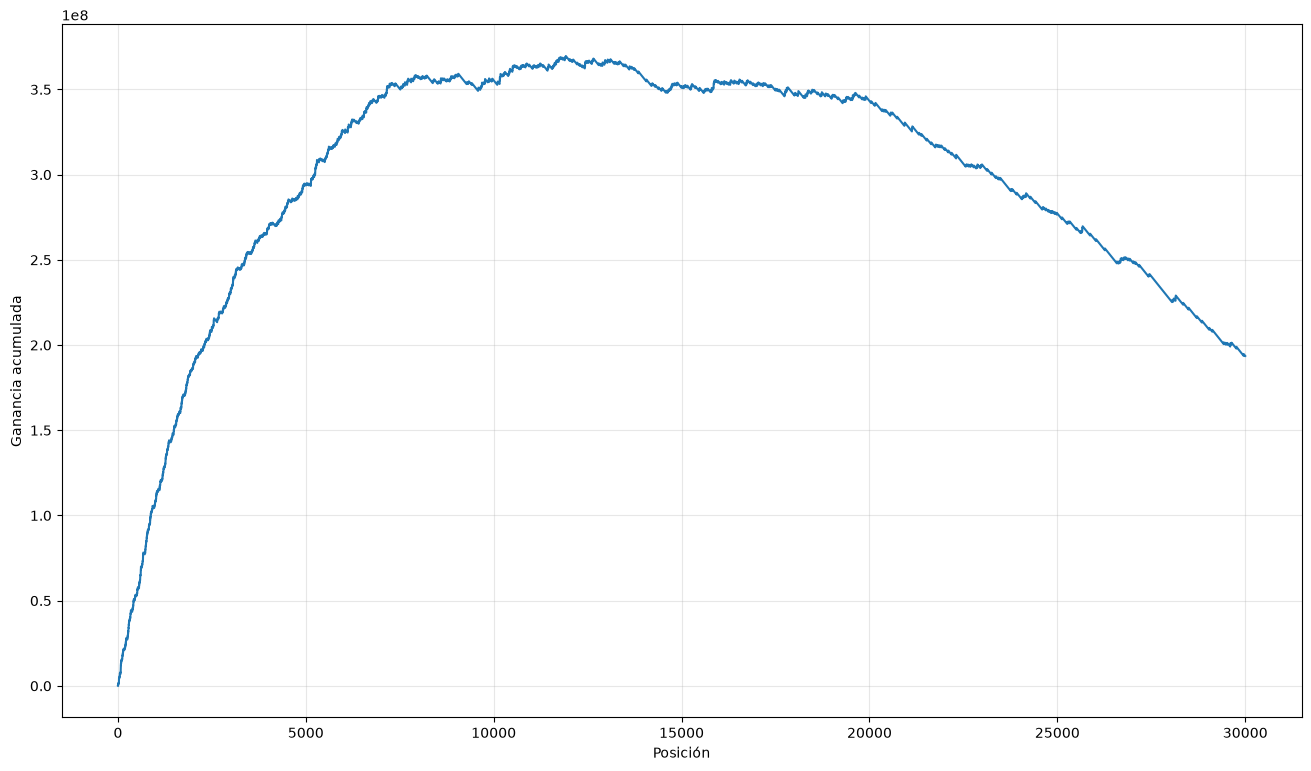

In [28]:
tb_prediccion = tb_prediccion.sort_values("prob", ascending=False).reset_index(drop=True)
tb_prediccion["gan"] = np.where(
    tb_prediccion["ternaria"].eq("BAJA+2"),
    1_072_500,
    -27_500,
)
tb_prediccion["ganancia_acumulada"] = tb_prediccion["gan"].cumsum()
tb_prediccion["pos"] = np.arange(1, len(tb_prediccion) + 1)

amostrar = 30_000
datos_plot = tb_prediccion.loc[tb_prediccion["pos"] <= amostrar]

plt.figure(figsize=(16, 9))
plt.plot(datos_plot["pos"], datos_plot["ganancia_acumulada"])
plt.xlabel("Posición")
plt.ylabel("Ganancia acumulada")
plt.grid(alpha=0.3)
plt.show()

## Ganancia bajo distintos cortes

In [31]:
resultados_cortes = []

for envios in PARAM["cortes"]:
    ganancia = tb_prediccion.iloc[:envios]["gan"].sum()
    resultados_cortes.append({
        "envios": envios,
        "ganancia": ganancia,
    })
    print(f"{envios}	{ganancia:.0f}")

resultados_cortes_df = pd.DataFrame(resultados_cortes)
resultados_cortes_df

9000	358600000
9500	351450000
10000	355300000
10500	361350000
11000	363000000
11500	363550000
12000	367400000
12500	365750000
13000	366300000
13500	363550000
14000	356400000
14500	350350000
15000	352000000


,envios,ganancia
0,9000,358600000
1,9500,351450000
2,10000,355300000
3,10500,361350000
4,11000,363000000
5,11500,363550000
6,12000,367400000
7,12500,365750000
8,13000,366300000
9,13500,363550000


In [30]:
with open(os.path.join(EXPERIMENT_URL, "PARAM.yml"), "w", encoding="utf-8") as archivo:
    yaml.safe_dump(PARAM, archivo, sort_keys=False, allow_unicode=True)